# Definitions

In [1]:
from IPython import get_ipython
get_ipython().run_line_magic('reset', '-sf')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#%matplotlib notebook
# Turn off interactive mode
plt.ioff()
plt.rcParams['interactive'] = False

#sns.set()
sns.set_style("ticks")
#sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})

#plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=30)  # fontsize of the axes title
plt.rc('axes', labelsize=30)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)  # fontsize of the tick labels
plt.rc('ytick', labelsize=30)  # fontsize of the tick labels
plt.rc('legend', fontsize=30)  # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('font', **{'family': 'serif', 'serif': ['Times New Roman']})
plt.rc('text', usetex=True)

plt.rc('xtick', direction='in') #xticks are plotted inside the figure
plt.rc('ytick', direction='in') #yticks are plotted inside the figure
plt.rcParams['xtick.major.pad'] = 10 #distance between ticks and numbers
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# set tick width and border width
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['axes.linewidth'] = 2



# One trajectory

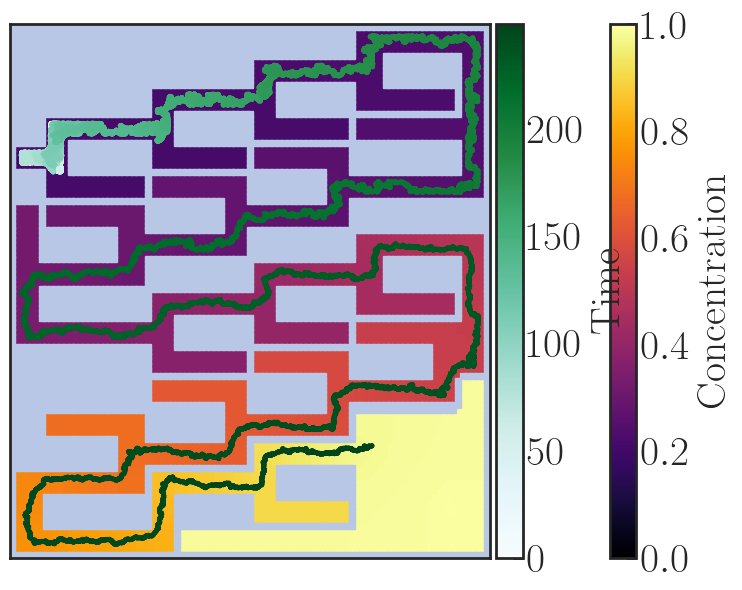

In [2]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
import os
import numpy as np

sys.path.append(os.path.join(os.getcwd(), 'strategy_comparison'))
from maze_functions import maze_from_file, load_c_from_file, load_traj_from_file

# Data directory
data = 'strategy_comparison/example_trajectories/CA/'

# Load the maze
maze = maze_from_file('strategy_comparison/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Load the concentration data
conc_from_file = load_c_from_file(maze, data +'conc_248598.txt')

# Load the particle trajectory
dx = 1
full_traj = load_traj_from_file(data +'full_traj.txt')

# Plot concentration map
fig, ax = plt.subplots(figsize=(8, 6))
conc = ax.imshow(conc_from_file.T/np.max(conc_from_file), interpolation=None, origin='lower', cmap=plt.cm.inferno, alpha=1.0)
cbar_conc= plt.colorbar(conc, label="Concentration", pad=0.03)

# Plot wall points
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=4, color='#B8C7E5')

# Plot particle trajectories
x_traj = full_traj[:, 1] / dx
y_traj = full_traj[:, 2] / dx
time = full_traj[:, 0]
#ax.plot(x_traj, y_traj,'.', markersize=0.8)
traj = ax.scatter(x_traj, y_traj, s=5 , c=time, cmap='BuGn', alpha=1.0)
cbar_traj = plt.colorbar(traj, label="Time", pad=0.01)


# Set axis labels
#ax.set_xlabel("x")
#ax.set_ylabel("y")
#ax.legend()
#fig.suptitle("Concentration map and Particle Trajectories")
plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()

#fig.savefig(data + '4.png', dpi=300, bbox_inches='tight')

# Two trajectories

/tmp/ipykernel_85469/1507141629.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


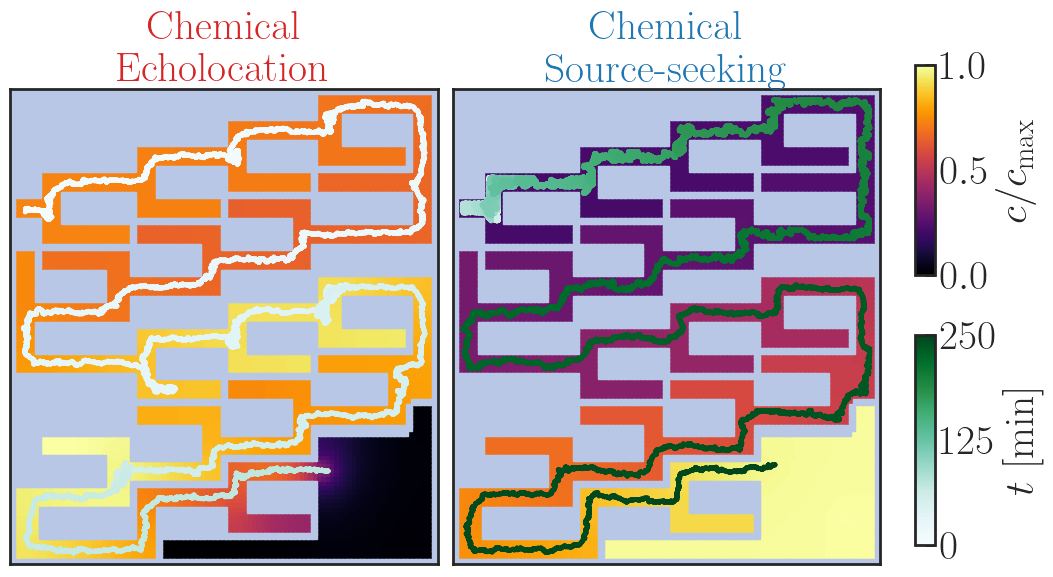

In [ ]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
import os
import numpy as np

sys.path.append(os.path.join(os.getcwd(), 'strategy_comparison'))
from maze_functions import maze_from_file, load_c_from_file, load_traj_from_file

# Data directory
data = 'strategy_comparison/example_trajectories/CA/'

# Load the maze
maze = maze_from_file('strategy_comparison/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharex=True, sharey=True)

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 1 # minutes
t_max = 250 * t_unit
r_unit = 1

##################################################################################
# Data directory for Chemorepulsion
data_CR = 'strategy_comparison/example_trajectories/CR/'

# Load the concentration data
conc_from_file_CR = load_c_from_file(maze, data_CR + 'conc_71869.txt')

# Load the particle trajectory
full_traj_CR = load_traj_from_file(data_CR + 'full_traj.txt')

# Plot concentration map for Chemorepulsion
conc_CR = ax[0].imshow(conc_from_file_CR.T / np.max(conc_from_file_CR), interpolation=None, origin='lower', cmap=plt.cm.inferno, alpha=1.0)

# Plot wall points
ax[0].plot(wall[:, 0], wall[:, 1], 's', markersize=4, color='#B8C7E5')

# Plot particle trajectories
x_traj_CR = full_traj_CR[:, 1]
y_traj_CR = full_traj_CR[:, 2]
time_CR = full_traj_CR[:, 0] * t_unit
traj_CR = ax[0].scatter(x_traj_CR, y_traj_CR, s=5, c=time_CR, vmax=t_max, cmap='BuGn', alpha=1.0)

ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Chemical\nEcholocation', color='tab:red', multialignment='center')
##################################################################################

##################################################################################
# Data directory for Chemoattraction
data_CA = 'strategy_comparison/example_trajectories/CA/'

# Load the concentration data
conc_from_file_CA = load_c_from_file(maze, data_CA + 'conc_248598.txt')

# Load the particle trajectory
full_traj_CA = load_traj_from_file(data_CA + 'full_traj.txt')

# Plot concentration map for Chemoattraction
conc_CA = ax[1].imshow(conc_from_file_CA.T / np.max(conc_from_file_CA), interpolation=None, origin='lower', cmap=plt.cm.inferno, alpha=1.0)

# Plot wall points
ax[1].plot(wall[:, 0], wall[:, 1], 's', markersize=4, color='#B8C7E5')

# Plot particle trajectories
x_traj_CA = full_traj_CA[:, 1]
y_traj_CA = full_traj_CA[:, 2]
time_CA = full_traj_CA[:, 0] * t_unit
traj_CA = ax[1].scatter(x_traj_CA, y_traj_CA, s=5, c=time_CA, vmax=t_max, cmap='BuGn', alpha=1.0)

ax[1].set_xticks([])
ax[1].set_yticks([])
#ax[1].set_title('Chemical source-seeking', color='tab:blue')
ax[1].set_title('Chemical\nSource-seeking', color='tab:blue', multialignment='center')
##################################################################################



# Add shared colorbars on the right
cbar_ax_conc = fig.add_axes([0.92, 0.55, 0.02, 0.35])  # Position: [left, bottom, width, height]
cbar_conc = fig.colorbar(conc_CA, cax=cbar_ax_conc)
cbar_conc.set_label(r'$c/c_{\mathrm{max}}$')


cbar_ax_time = fig.add_axes([0.92, 0.1, 0.02, 0.35])  # Position: [left, bottom, width, height]
cbar_time = fig.colorbar(traj_CA, cax=cbar_ax_time)
cbar_time.set_label(r'$t$ [min]')
cbar_time.set_ticks([0, 125, 250])

# Set axis labels and layout
fig.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


# Save the figure
#fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'trajectory_compare.png', dpi=300, bbox_inches='tight')


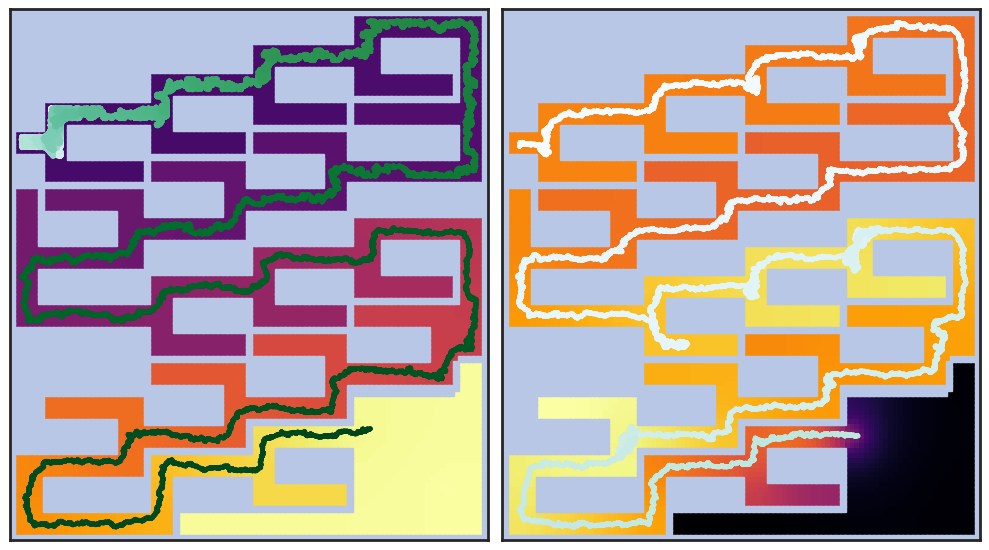

In [7]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
import os
import numpy as np

sys.path.append(os.path.join(os.getcwd(), 'strategy_comparison'))
from maze_functions import maze_from_file, load_c_from_file, load_traj_from_file

# Data directory
data = 'strategy_comparison/example_trajectories/CA/'

# Load the maze
maze = maze_from_file('strategy_comparison/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharex=True, sharey=True)
vmax = 250

##################################################################################
# Data directory for Chemoattraction
data_CA = 'strategy_comparison/example_trajectories/CA/'

# Load the concentration data
conc_from_file_CA = load_c_from_file(maze, data_CA + 'conc_248598.txt')

# Load the particle trajectory
full_traj_CA = load_traj_from_file(data_CA + 'full_traj.txt')

# Plot concentration map
conc = ax[0].imshow(conc_from_file_CA.T/np.max(conc_from_file_CA), interpolation=None, origin='lower', cmap=plt.cm.inferno, alpha=1.0)
#cbar_conc= plt.colorbar(conc, label="Concentration", pad=0.03)

# Plot wall points
ax[0].plot(wall[:, 0], wall[:, 1], 's', markersize=4, color='#B8C7E5')

# Plot particle trajectories
x_traj = full_traj_CA[:, 1] 
y_traj = full_traj_CA[:, 2] 
time = full_traj_CA[:, 0]
#ax.plot(x_traj, y_traj,'.', markersize=0.8)
traj = ax[0].scatter(x_traj, y_traj, s=5 , c=time, vmax=vmax, cmap='BuGn', alpha=1.0)
#cbar_traj = plt.colorbar(traj, label="Time", pad=0.01)

ax[0].set_xticks([])
ax[0].set_yticks([])
##################################################################################

##################################################################################
# Data directory for Chemorepulsion
data_CR = 'strategy_comparison/example_trajectories/CR/'

# Load the concentration data
conc_from_file_CR = load_c_from_file(maze, data_CR + 'conc_71869.txt')

# Load the particle trajectory
full_traj_CR = load_traj_from_file(data_CR + 'full_traj.txt')

# Plot concentration map
conc = ax[1].imshow(conc_from_file_CR.T/np.max(conc_from_file_CR), interpolation=None, origin='lower', cmap=plt.cm.inferno, alpha=1.0)
#cbar_conc= plt.colorbar(conc, label="Concentration", pad=0.03)

# Plot wall points
ax[1].plot(wall[:, 0], wall[:, 1], 's', markersize=4, color='#B8C7E5')

# Plot particle trajectories
x_traj = full_traj_CR[:, 1] / dx
y_traj = full_traj_CR[:, 2] / dx
time = full_traj_CR[:, 0]
traj = ax[1].scatter(x_traj, y_traj, s=5 , c=time, vmax=vmax, cmap='BuGn', alpha=1.0)
#cbar_traj = plt.colorbar(traj, label="Time", pad=0.01)

ax[1].set_xticks([])
ax[1].set_yticks([])
##################################################################################

# Set axis labels
#ax.set_xlabel("x")
#ax.set_ylabel("y")
#ax.legend()
#fig.suptitle("Concentration map and Particle Trajectories")
plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()


#fig.savefig(data + '4.png', dpi=300, bbox_inches='tight')